# Mach # vs. Skewness for a Wavy Field with Geometric Depolarization 

#### Wavy field model
- turbulence 
- Bz component
- Wavy structure
- Geometric depolarization via varying amplitude of wavy along LOS

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def wavy_field_depol_test(M_A, Bz_true, amplitude_range, g_size, plotting=False):
    """
    ISM toy polarization model with LOS turbulence parameterized
    by Alfvénic Mach number M_A.
    """

    # =========================
    # REGIME CLASSIFICATION
    # =========================
    if M_A < 0.5:
        regime = "sub-Alfvénic"
        sigma_phi = M_A
    elif 0.5 <= M_A <= 1.0:
        regime = "trans-Alfvénic"
        sigma_phi = M_A
    else:
        regime = "super-Alfvénic"
        # Saturate angular dispersion (randomized field limit)
        # sigma_phi = np.pi / 2
        sigma_phi = M_A
        regime = "Super-Alfvénic regime: angular dispersion saturated; DCF assumptions invalid."

    # print(f"Operating regime: {regime} (M_A = {M_A:.2f})")

    # =========================
    # PARAMETERS
    # =========================
    I0 = 1.0
    frequency = 1.0
    amplitude = np.linspace(amplitude_range[0], amplitude_range[1], g_size)

    Bx0, By0 = 1.0, 1.0
    corr_r = 0.9   # LOS correlation coefficient

    # =========================
    # GRID
    # =========================
    x = np.linspace(-np.pi, np.pi, g_size)
    y = np.linspace(-np.pi, np.pi, g_size)
    z = np.linspace(-np.pi, np.pi, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

    Bx = np.zeros_like(X)
    By = np.zeros_like(Y)
    Bz = np.zeros_like(Z)

    # =========================
    # LARGE-SCALE POS FIELD
    # =========================
    for iz in range(g_size):
        theta0 = amplitude[iz] * np.cos(frequency * X[:, :, iz])
        Bx[:, :, iz] = Bx0 * np.cos(theta0)
        By[:, :, iz] = By0 * np.sin(theta0)
        Bz[:, :, iz] = Bz_true

    # =========================
    # LOS TURBULENCE (AR(1))
    # =========================
    delta_theta = np.zeros((g_size, g_size, g_size))

    for ix in range(g_size):
        for iy in range(g_size):
            val = np.random.normal(scale=sigma_phi)
            for iz in range(g_size):
                delta_theta[ix, iy, iz] = val
                val = corr_r * val + np.random.normal(
                    scale=sigma_phi * np.sqrt(1 - corr_r**2)
                )

    # =========================
    # APPLY TURBULENT ROTATION
    # =========================
    Bx_rot = Bx * np.cos(delta_theta) - By * np.sin(delta_theta)
    By_rot = Bx * np.sin(delta_theta) + By * np.cos(delta_theta)

    Bx, By = Bx_rot, By_rot

    # =========================
    # OPTIONAL FIELD PLOTTING
    # =========================
    if plotting:
        fig, ax = plt.subplots(1, g_size, figsize=(18, 2))
        for iz in range(g_size):
            ax[iz].quiver(
                X[:, :, iz], Y[:, :, iz],
                Bx[:, :, iz], By[:, :, iz],
                pivot="middle",
                scale=2,
                scale_units="xy",
                headlength=0,
                headaxislength=0
            )
            ax[iz].set_title(f"z={iz}")
        plt.tight_layout()
        plt.show()

    # =========================
    # STOKES FROM FIELD
    # =========================
    Bperp2 = Bx**2 + By**2
    Btot2 = Bperp2 + Bz**2 + 1e-12

    cos2g = Bperp2 / Btot2
    q = (By**2 - Bx**2) / Btot2
    u = (2 * Bx * By) / Btot2

    Q3 = I0 * q
    U3 = I0 * u

    # =========================
    # LOS INTEGRATION
    # =========================
    Q_obs = Q3.sum(axis=2)
    U_obs = U3.sum(axis=2)
    I_obs = I0 * g_size

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / I_obs
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)
    cos2g_LOS = cos2g.mean(axis=2)

    return P_obs, phi_obs, cos2g_LOS


### Plots:
- Distributions of polarization fraction 
- Mach # vs. Skewness


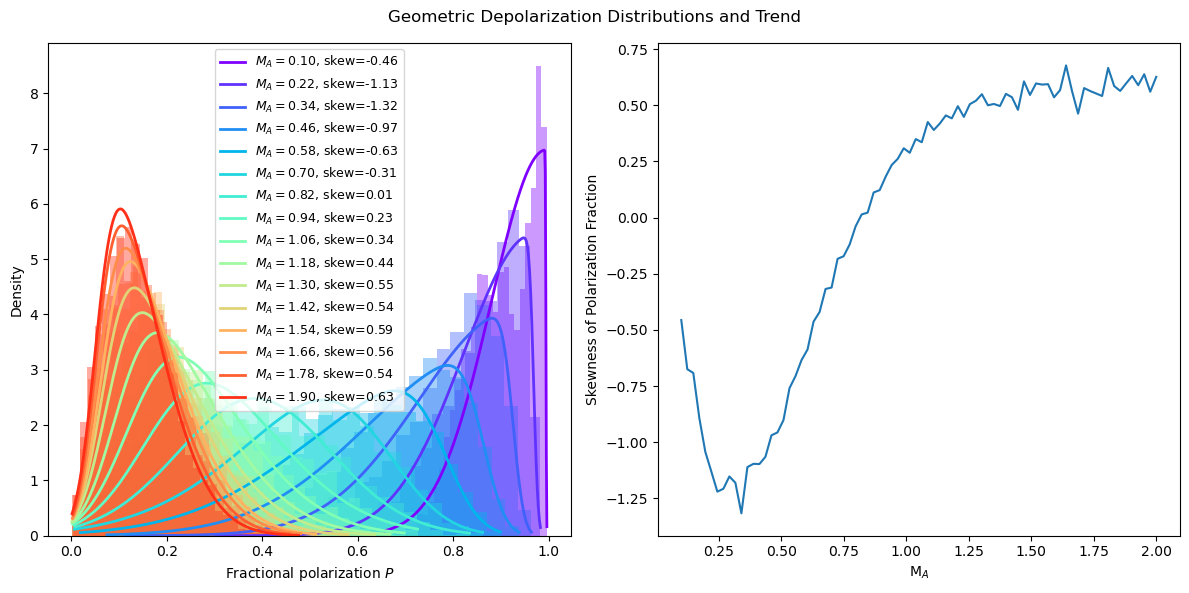

In [18]:
from scipy.stats import skew, skewnorm
fig, ax = plt.subplots(1,2,figsize=(12,6))
mach_vals = np.linspace(0.1,2,80)
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

skews = []
for i in range(len(mach_vals)):

    # simulate
    P, PHI, C = wavy_field_depol_test(M_A=mach_vals[i],Bz_true=0,amplitude_range=[0, 1],g_size=64,plotting=False)

    # flatten & clip to >0
    Pflat = P.flatten()
    Pflat = Pflat[Pflat > 0]

    # --- compute raw skewness ---
    skew_val = skew(Pflat, bias=False)
    skews.append(skew_val)

    # --- fit skewnormal distribution ---
    # skewnorm.fit returns (a, loc, scale)
    a, loc, scale = skewnorm.fit(Pflat)

    # build PDF for plotting
    x = np.linspace(Pflat.min(), Pflat.max(), 300)
    pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

    if i%5 == 0:
        # --- histogram ---
        ax[0].hist(Pflat, bins=30, density=True, alpha=0.4, color = color[i])
        # --- overlay skewnormal fit ---
        ax[0].plot(x, pdf_skew, lw=2, label=rf"$M_A={mach_vals[i]:.2f}$, skew={skew_val:.2f}", color=color[i])

ax[0].set_xlabel("Fractional polarization $P$")
ax[0].set_ylabel("Density")
ax[0].legend(fontsize=9)

ax[1].plot(mach_vals, skews, linestyle='-')
ax[1].set_xlabel(r'M$_A$')
ax[1].set_ylabel('Skewness of Polarization Fraction')


fig.suptitle('Geometric Depolarization Distributions and Trend')
plt.tight_layout()
plt.show()


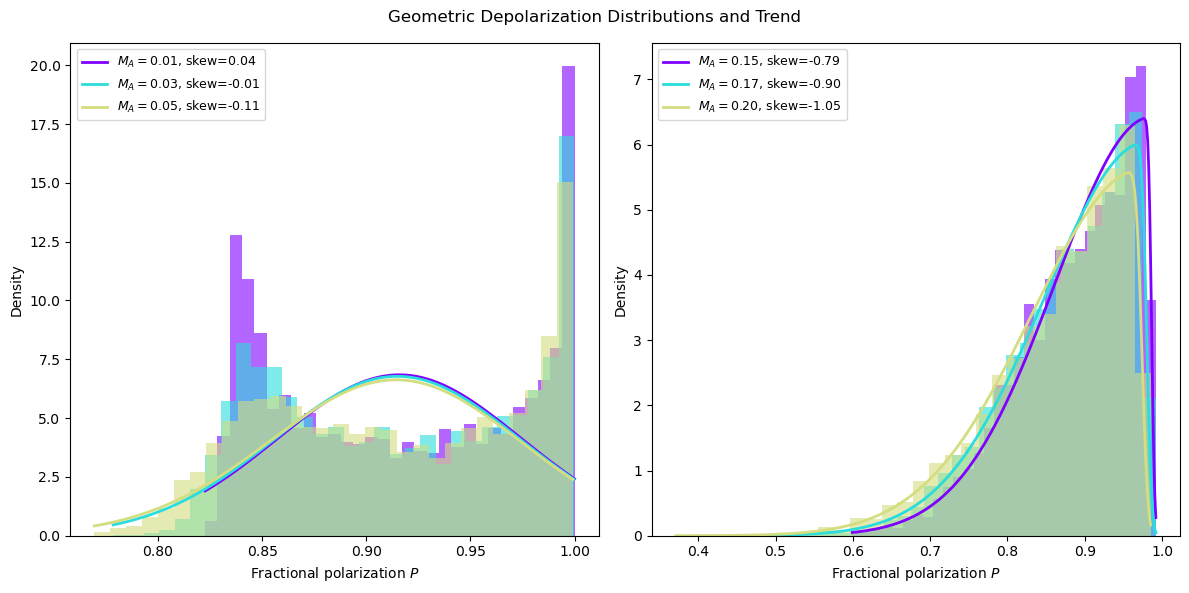

In [19]:
from scipy.stats import skew, skewnorm
fig, ax = plt.subplots(1,2,figsize=(12,6))

n = 3
mach_vals_1 = np.linspace(0.01,0.05,n)
mach_vals_2 = np.linspace(0.15,0.2,n)

color = plt.cm.rainbow(np.linspace(0,1,n+1))

skews1 = []
skews2 = []
for i in range(n):

    # simulate
    P1, PHI1, C1 = wavy_field_depol_test(M_A=mach_vals_1[i],Bz_true=0,amplitude_range=[0, 1],g_size=64,plotting=False)
    P2, PHI2, C2 = wavy_field_depol_test(M_A=mach_vals_2[i],Bz_true=0,amplitude_range=[0, 1],g_size=64,plotting=False)

    Pflat1 = P1.flatten()
    Pflat1 = Pflat1[Pflat1 > 0]
    skew_val1 = skew(Pflat1, bias=False)
    skews1.append(skew_val1)
    a1, loc1, scale1 = skewnorm.fit(Pflat1)
    x1 = np.linspace(Pflat1.min(), Pflat1.max(), 300)
    pdf_skew1 = skewnorm.pdf(x1, a1, loc=loc1, scale=scale1)

    Pflat2 = P2.flatten()
    Pflat2 = Pflat2[Pflat2 > 0]
    skew_val2 = skew(Pflat2, bias=False)
    skews2.append(skew_val2)
    a2, loc2, scale2 = skewnorm.fit(Pflat2)
    x2 = np.linspace(Pflat2.min(), Pflat2.max(), 300)
    pdf_skew2 = skewnorm.pdf(x2, a2, loc=loc2, scale=scale2)

    # --- plot ---
    ax[0].hist(Pflat1, bins=30, density=True, alpha=0.6, color = color[i])
    ax[0].plot(x1, pdf_skew1, lw=2, label=rf"$M_A={mach_vals_1[i]:.2f}$, skew={skew_val1:.2f}", color=color[i])

    ax[1].hist(Pflat2, bins=30, density=True, alpha=0.6, color = color[i])
    ax[1].plot(x2, pdf_skew2, lw=2, label=rf"$M_A={mach_vals_2[i]:.2f}$, skew={skew_val2:.2f}", color=color[i])

ax[0].set_xlabel("Fractional polarization $P$")
ax[0].set_ylabel("Density")
ax[0].legend(fontsize=9)

ax[1].set_xlabel("Fractional polarization $P$")
ax[1].set_ylabel("Density")
ax[1].legend(fontsize=9)


fig.suptitle('Geometric Depolarization Distributions and Trend')
plt.tight_layout()
plt.show()


### Zoom in on trend above, highlighting different Mach # sections

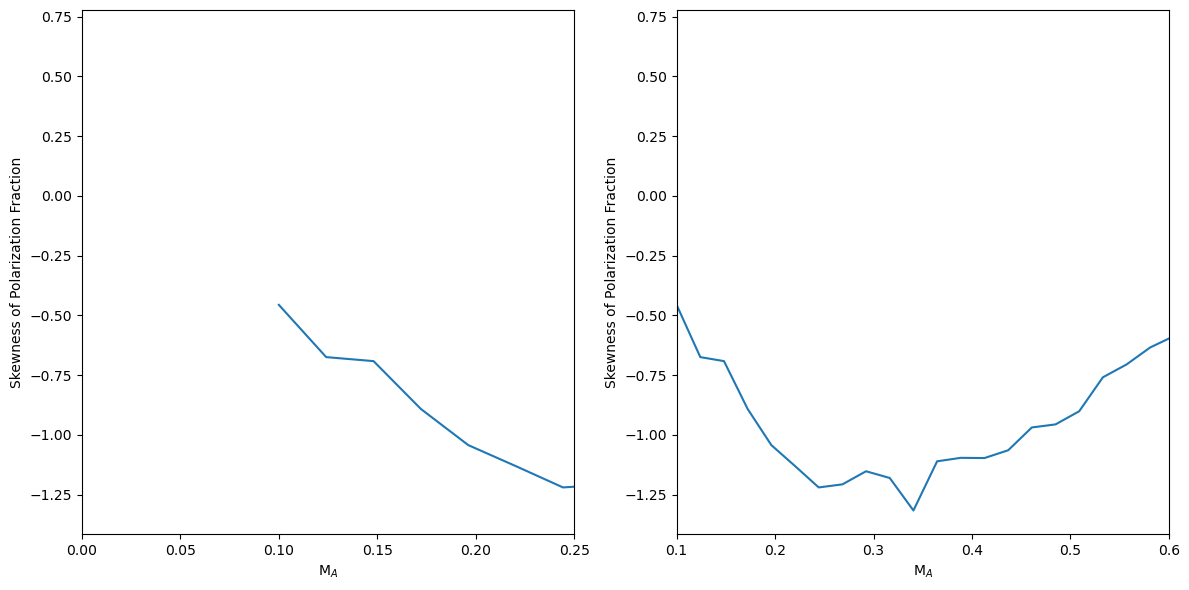

In [20]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(mach_vals, skews, linestyle='-')
ax[0].set_xlabel(r'M$_A$')
ax[0].set_ylabel('Skewness of Polarization Fraction')
ax[0].set_xlim([0,0.25])

ax[1].plot(mach_vals, skews, linestyle='-')
ax[1].set_xlabel(r'M$_A$')
ax[1].set_ylabel('Skewness of Polarization Fraction')
ax[1].set_xlim([0.1,0.6])


plt.tight_layout()
plt.show()

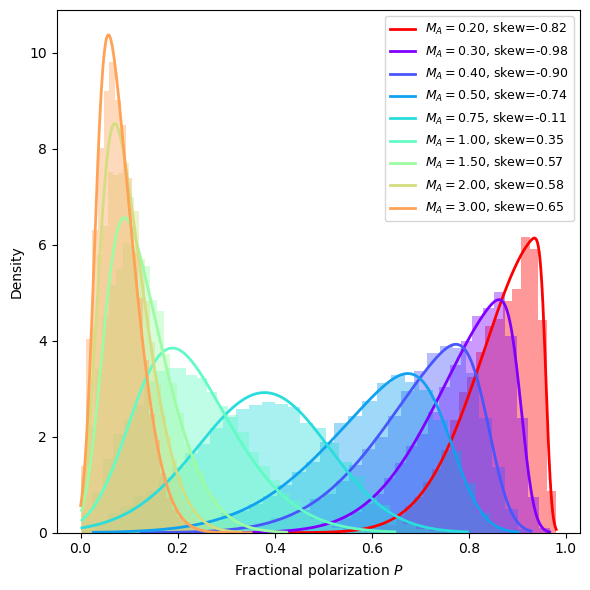

In [27]:
from scipy.stats import skew, skewnorm
plt.figure(figsize=(6, 6))
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
# mach_vals = [0.01,0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.15, 0.2,0.3,0.4,0.5,1,2]
# mach_vals = [0.01,0.02,0.03,0.04,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,]
# mach_vals = [0.001,0.01,0.02,0.03,0.04,0.05,0.1]
skews = []
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

for imach in mach_vals:

    # simulate
    P, PHI, C = wavy_field_depol_test(M_A=imach,Bz_true=0,amplitude_range=[0, 1],g_size=128,plotting=False)

    # flatten & clip to >0
    Pflat = P.flatten()
    Pflat = Pflat[Pflat > 0]

    # --- compute raw skewness ---
    skew_val = skew(Pflat, bias=False)
    skews.append(skew_val)

    # --- fit skewnormal distribution ---
    # skewnorm.fit returns (a, loc, scale)
    a, loc, scale = skewnorm.fit(Pflat)

    # build PDF for plotting
    x = np.linspace(Pflat.min(), Pflat.max(), 300)
    pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

    # --- histogram ---
    plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

    # --- overlay skewnormal fit ---
    plt.plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color=color[mach_vals.index(imach)-1])

plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
# plt.yscale('log')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


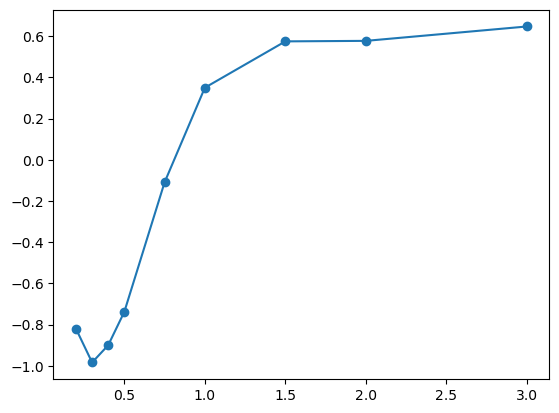

In [28]:
plt.plot(mach_vals, skews, marker='o')

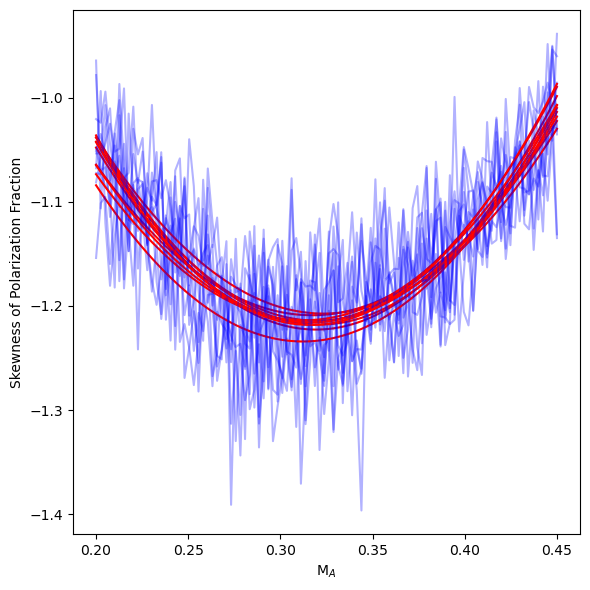

In [23]:
from scipy.stats import skew, skewnorm
plt.figure(figsize=(6, 6))
mach_vals = np.linspace(0.2,0.45,100)
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))
ntrials = 10


for n in range(ntrials):
    skews = []
    for i in range(len(mach_vals)):

        # No geometric depolarization
        P, PHI, C = wavy_field_depol_test(M_A=mach_vals[i],Bz_true=0,amplitude_range=[0, 1],g_size=64,plotting=False)
        Pflat = P.flatten()
        Pflat = Pflat[Pflat > 0]
        skew_val = skew(Pflat, bias=False)
        skews.append(skew_val)
        a, loc, scale = skewnorm.fit(Pflat)
        x = np.linspace(Pflat.min(), Pflat.max(), 300)
        pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)
        
        # if i%5 == 0:
        #     ax[0].hist(Pflat, bins=30, density=True, alpha=0.4, color = 'red')
        #     ax[0].plot(x, pdf_skew, lw=2, color='red',alpha=0.5, color = 'blue')

    coeffs, cov = np.polyfit(mach_vals, skews, deg=2, cov=True)
    p2 = np.poly1d(coeffs)
    x_smooth = np.linspace(mach_vals.min(), mach_vals.max(), 100)
    y_smooth = p2(x_smooth)

    plt.plot(x_smooth, y_smooth, 'r-')

    plt.plot([], [], color='red', label='With geometric depolarization')

    plt.plot(mach_vals, skews, linestyle='-', color='blue', alpha=0.3)

plt.xlabel(r'M$_A$')
plt.ylabel('Skewness of Polarization Fraction')


plt.tight_layout()
plt.show()

In [25]:
index_min= np.where(y_smooth==min(y_smooth))

print(f"Minimum skewness at M_A = {x_smooth[index_min][0]:.3f}, {y_smooth[index_min][0]:.3f}")


Minimum skewness at M_A = 0.316, -1.218


# Add turbulence to all components and add Div(B) = 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def wavy_field_depol_test2(M_A, Bz_true, amplitude_range, g_size, plotting=False):
    """
    ISM toy polarization model with LOS turbulence parameterized
    by Alfvénic Mach number M_A.
    """

    # PARAMETERS
    sigma_phi = M_A
    I0 = 1.0
    frequency = 1.0
    amplitude = np.linspace(amplitude_range[0], amplitude_range[1], g_size)

    Bx0, By0 = 1.0, 1.0
    corr_r = 0.9   # LOS correlation coefficient

    # =========================
    # GRID
    # =========================
    x = np.linspace(-np.pi, np.pi, g_size)
    y = np.linspace(-np.pi, np.pi, g_size)
    z = np.linspace(-np.pi, np.pi, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

    Bx = np.zeros_like(X)
    By = np.zeros_like(Y)
    Bz = np.zeros_like(Z)

    # =========================
    # LARGE-SCALE POS FIELD
    # =========================
    for iz in range(g_size):
        theta0 = amplitude[iz] * np.cos(frequency * X[:, :, iz])
        Bx[:, :, iz] = Bx0 * np.cos(theta0)
        By[:, :, iz] = By0 * np.sin(theta0)
        Bz[:, :, iz] = Bz_true

    # =========================
    # LOS TURBULENCE (AR(1))
    # =========================
    delta_theta = np.zeros((g_size, g_size, g_size))

    for ix in range(g_size):
        for iy in range(g_size):
            val = np.random.normal(scale=sigma_phi)
            for iz in range(g_size):
                delta_theta[ix, iy, iz] = val
                val = corr_r * val + np.random.normal(
                    scale=sigma_phi * np.sqrt(1 - corr_r**2)
                )

    # =========================
    # APPLY TURBULENT ROTATION
    # =========================
    Bx_rot = Bx * np.cos(delta_theta) - By * np.sin(delta_theta)
    By_rot = Bx * np.sin(delta_theta) + By * np.cos(delta_theta)

    Bx, By = Bx_rot, By_rot

    # =========================
    # ENFORCE DIVERGENCE-FREE FIELD
    # =========================
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    kx = np.fft.fftfreq(g_size, d=dx) * 2*np.pi
    ky = np.fft.fftfreq(g_size, d=dy) * 2*np.pi
    kz = np.fft.fftfreq(g_size, d=dz) * 2*np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="xy")

    Bx_k = np.fft.fftn(Bx)
    By_k = np.fft.fftn(By)
    Bz_k = np.fft.fftn(Bz)

    k2 = KX**2 + KY**2 + KZ**2
    mask = k2 > 0

    k_dot_B = KX*Bx_k + KY*By_k + KZ*Bz_k

    Bx_k[mask] -= KX[mask] * k_dot_B[mask] / k2[mask]
    By_k[mask] -= KY[mask] * k_dot_B[mask] / k2[mask]
    Bz_k[mask] -= KZ[mask] * k_dot_B[mask] / k2[mask]

    Bx = np.fft.ifftn(Bx_k).real
    By = np.fft.ifftn(By_k).real
    Bz = np.fft.ifftn(Bz_k).real
    
    # # =========================
    # # DIVERGENCE-FREE TURBULENCE (3D)
    # # =========================
    # sigma_B = M_A

    # # random Gaussian vector field in Fourier space
    # kx = np.fft.fftfreq(g_size, d=(x[1]-x[0])) * 2*np.pi
    # ky = np.fft.fftfreq(g_size, d=(y[1]-y[0])) * 2*np.pi
    # kz = np.fft.fftfreq(g_size, d=(z[1]-z[0])) * 2*np.pi
    # KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="xy")

    # # random complex field
    # Fx = np.random.normal(size=X.shape) + 1j*np.random.normal(size=X.shape)
    # Fy = np.random.normal(size=X.shape) + 1j*np.random.normal(size=X.shape)
    # Fz = np.random.normal(size=X.shape) + 1j*np.random.normal(size=X.shape)

    # # project out compressive component: F -> F_perp
    # k2 = KX**2 + KY**2 + KZ**2
    # k2[0,0,0] = 1.0  # avoid divide by zero

    # k_dot_F = KX*Fx + KY*Fy + KZ*Fz

    # Fx -= KX * k_dot_F / k2
    # Fy -= KY * k_dot_F / k2
    # Fz -= KZ * k_dot_F / k2

    # # back to real space
    # dBx = np.fft.ifftn(Fx).real
    # dBy = np.fft.ifftn(Fy).real
    # dBz = np.fft.ifftn(Fz).real

    # # normalize turbulence strength
    # rms = np.sqrt(np.mean(dBx**2 + dBy**2 + dBz**2))
    # dBx *= sigma_B / rms
    # dBy *= sigma_B / rms
    # dBz *= sigma_B / rms

    # # add turbulence to large-scale field
    # Bx += dBx
    # By += dBy
    # Bz += dBz



    
    # =========================
    # OPTIONAL FIELD PLOTTING
    # =========================
    if plotting:
        fig, ax = plt.subplots(1, g_size, figsize=(18, 2))
        for iz in range(g_size):
            ax[iz].quiver(
                X[:, :, iz], Y[:, :, iz],
                Bx[:, :, iz], By[:, :, iz],
                pivot="middle",
                scale=2,
                scale_units="xy",
                headlength=0,
                headaxislength=0
            )
            ax[iz].set_title(f"z={iz}")
        plt.tight_layout()
        plt.show()

    # =========================
    # STOKES FROM FIELD
    # =========================
    Bperp2 = Bx**2 + By**2
    Btot2 = Bperp2 + Bz**2 + 1e-12

    cos2g = Bperp2 / Btot2
    q = (By**2 - Bx**2) / Btot2
    u = (2 * Bx * By) / Btot2

    Q3 = I0 * q
    U3 = I0 * u

    # =========================
    # LOS INTEGRATION
    # =========================
    Q_obs = Q3.sum(axis=2)
    U_obs = U3.sum(axis=2)
    I_obs = I0 * g_size

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / I_obs
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)
    cos2g_LOS = cos2g.mean(axis=2)

    return P_obs, phi_obs, cos2g_LOS


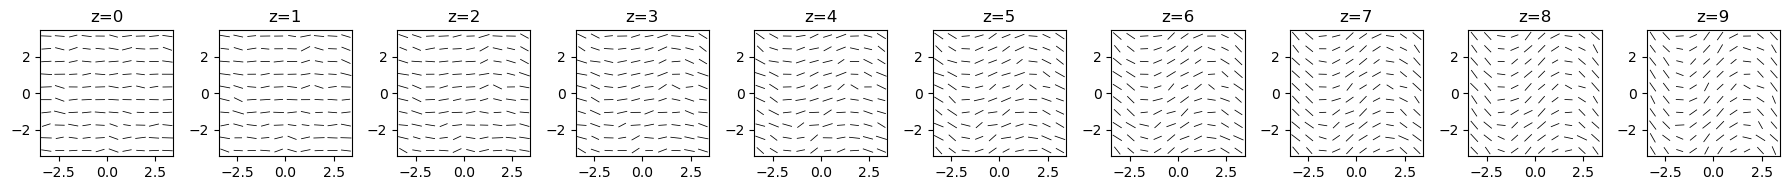

In [37]:
P, PHI, C = wavy_field_depol_test2(M_A=0.25, Bz_true = 0, amplitude_range = [0,1], g_size = 10, plotting = True)

In [38]:
P, PHI, C = wavy_field_depol_test2(M_A = 0.3, Bz_true = 0, amplitude_range = [1,1], 
                                      g_size = 64, plotting = False)
print(P)

[[0.92339651 0.96757756 0.94371443 ... 0.9236026  0.94538307 0.93720414]
 [0.9407981  0.95333725 0.87685943 ... 0.96254351 0.97496938 0.94694278]
 [0.96087859 0.90384132 0.94032576 ... 0.94530491 0.94067998 0.96612767]
 ...
 [0.95211261 0.95308191 0.96210769 ... 0.9674966  0.97433534 0.95114392]
 [0.97198133 0.96916795 0.91342267 ... 0.93820293 0.97772468 0.94998044]
 [0.95183729 0.97926933 0.97839762 ... 0.95214383 0.96406179 0.96286666]]


Text(0.5, 1.0, 'Wavy Field; divB=0, 3D turbulence')

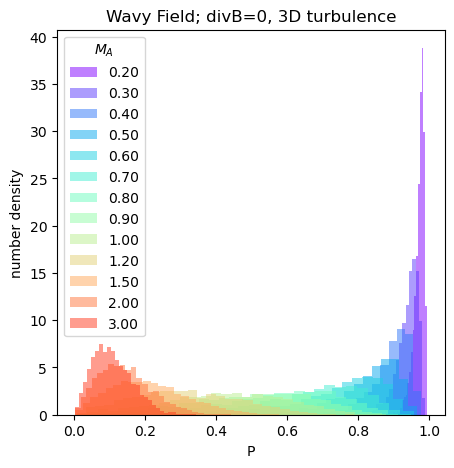

In [39]:
# mach_vals = [0.25,0.5,0.75,1,3]#np.linspace(0,2,4)
# mach_vals = np.linspace(0.2,1,10)
# mach_vals = [0.01,0.02, 0.03, 0.04, 0.05, 0.07, 0.1]
mach_vals = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.2,1.5,2,3]

plt.figure(figsize=(5,5))

for imach in mach_vals:
    P, PHI, C = wavy_field_depol_test2(M_A = imach, Bz_true = 0, amplitude_range = [1,1], 
                                      g_size = 64, plotting = False)
    plt.hist(P.flatten(), bins=30, alpha=0.5, label=f"{imach:.2f}", density=True, color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))
plt.xlabel("P")
plt.ylabel('number density')
plt.legend(title=r'$M_A$')
plt.title('Wavy Field; divB=0, 3D turbulence')
# plt.ylim(0,2000)

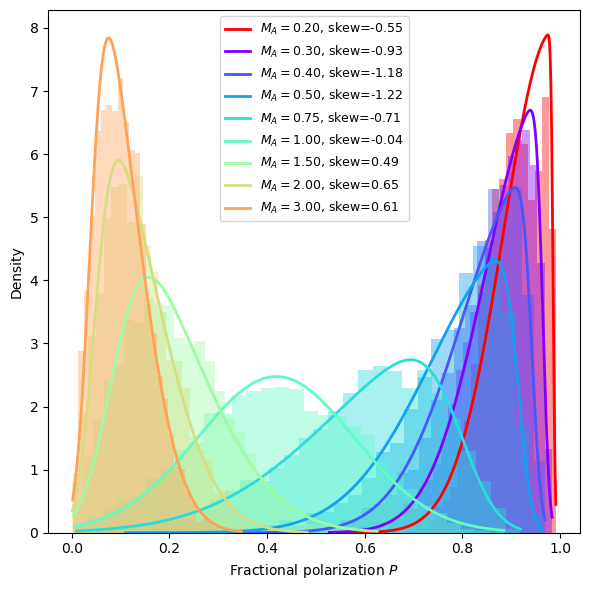

In [42]:
from scipy.stats import skew, skewnorm
plt.figure(figsize=(6, 6))
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
skews = []
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

for imach in mach_vals:

    # simulate
    P, PHI, C = wavy_field_depol_test2(M_A=imach,Bz_true=0,amplitude_range=[0, 1],g_size=64,plotting=False)

    # flatten & clip to >0
    Pflat = P.flatten()
    Pflat = Pflat[Pflat > 0]

    # --- compute raw skewness ---
    skew_val = skew(Pflat, bias=False)
    skews.append(skew_val)

    # --- fit skewnormal distribution ---
    # skewnorm.fit returns (a, loc, scale)
    a, loc, scale = skewnorm.fit(Pflat)

    # build PDF for plotting
    x = np.linspace(Pflat.min(), Pflat.max(), 300)
    pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

    # --- histogram ---
    plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

    # --- overlay skewnormal fit ---
    plt.plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color=color[mach_vals.index(imach)-1])

plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
# plt.yscale('log')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


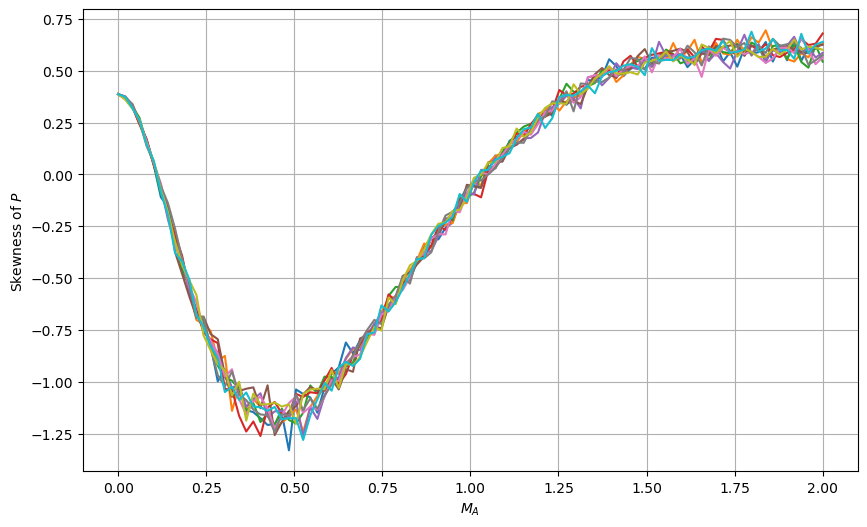

In [43]:
plt.figure(figsize=(10, 6))
n = 10
for i in range(n):
    skews = []
    mach_vals = np.linspace(0,2,100)
    # mach_vals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.5,4,4.5,5]
    for imach in mach_vals:
        P, PHI, C = wavy_field_depol_test2(M_A=imach, Bz_true=0, amplitude_range=[0, 1], g_size=64, plotting=False)
        skews.append(skew(P.flatten(), bias=False))

    plt.plot(mach_vals, skews, linestyle='-')
    
plt.xlabel(r"$M_A$")
plt.ylabel("Skewness of $P$")
plt.grid(True)
plt.show()